In [1]:
import sys

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from agn_radio_catalogue import (
    AstrogeoAGNCatalogue, AverageFluxWeightHypothesis
)
from alertstack import alertstack_data_dir, is_outside_GP
from astropy.io import fits
from blazar_catalogue import (
    Fermi4FGLBlazarCatalogue, AverageFluxWeightHypothesis, data_lc
)

In [2]:
rd_cat_obj = AstrogeoAGNCatalogue()

In [3]:
rd_cat_obj.data

,Comm name,Source_Name,ra_deg,dec_deg,N of obs,S band map,S band unresolved,C band map,C band unresolved,X band map,X band unresolved,U band map,U band unresolved,K band map,K band unresolved,ra_rad,dec_rad,bkg_pdf
0,2357-326,J0000-3221,0.085000,-32.350343,17,0.581,0.436,-9.99,-9.99,0.278,0.133,-9.99,-9.99,-9.99,-9.99,0.001484,-0.564620,6.901887e-310
1,2358+406,J0000+4054,0.221171,40.900503,16,0.802,0.116,-9.99,-9.99,0.238,0.051,-9.99,-9.99,-9.99,-9.99,0.003860,0.713848,6.901887e-310
2,2358-161,J0001-1551,0.272203,-15.851965,18,0.313,0.179,-9.99,-9.99,0.192,0.099,-9.99,-9.99,-9.99,-9.99,0.004751,-0.276669,4.646228e-310
3,2358+189,J0001+1914,0.285923,19.242723,770,0.255,0.195,0.156,0.127,0.251,0.186,-9.99,-9.99,-9.99,-9.99,0.004990,0.335849,4.646228e-310
4,2358-080,J0001-0746,0.325104,-7.774145,28,0.209,0.106,-9.99,-9.99,0.175,0.053,-9.99,-9.99,-9.99,-9.99,0.005674,-0.135684,-1.356844e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3378,2355+042,J2358+0430,359.620196,4.506899,23,0.188,0.165,-9.99,-9.99,0.153,0.105,-9.99,-9.99,-9.99,-9.99,6.276556,0.078660,7.866023e-02
3379,2356+196,J2358+1955,359.692021,19.922306,85,0.773,0.502,-9.99,-9.99,0.469,0.221,0.377,0.182,-9.99,-9.99,6.277810,0.347710,3.477098e-01
3380,2356+390,J2358+3922,359.749396,39.374529,16,0.326,0.117,-9.99,-9.99,0.305,0.180,-9.99,-9.99,-9.99,-9.99,6.278811,0.687215,6.872152e-01
3381,2356+385,J2359+3850,359.888253,38.845088,9256,0.416,0.297,-9.99,-9.99,0.320,0.206,-9.99,-9.99,-9.99,-9.99,6.281235,0.677975,6.779747e-01


In [4]:
rd_cat_obj.data["X band map"]

0       0.278
1       0.238
2       0.192
3       0.251
4       0.175
        ...  
3378    0.153
3379    0.469
3380    0.305
3381    0.320
3382    0.463
Name: X band map, Length: 3383, dtype: float64

In [5]:
len(rd_cat_obj.data)

3383

In [6]:
alertstack_data_dir = "../data/"
with fits.open(os.path.join(alertstack_data_dir, "table-4LAC-DR3-h.fits")) as hdul:
    cat = hdul[1].data
    header = hdul[1].header
cat = np.sort(cat, order="Energy_Flux100")[::-1]

#blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]

mask = np.array([x["CLASS"] in blazar_class for x in cat])
blazars = np.array(cat[mask])
mask_e = np.array([x["Energy_Flux100"]>10**(-11.6) for x in blazars])
fermi_df = np.array(blazars[mask_e])
#fermi_df = fermicat.data
#fermi_df.keys()

In [7]:
fermi_ra = fermi_df["RA_Counterpart"]
fermi_de = fermi_df["DEC_Counterpart"]
fermi_er = fermi_df["Unc_Counterpart"]

In [8]:
radio_df = rd_cat_obj.data
rfc_ra = radio_df["ra_deg"]
rfc_de = radio_df["dec_deg"]

In [9]:
ang_mask = np.array([
    sum(
        (
            ra < ( fermi_ra + fermi_er / np.cos(fermi_de * np.pi / 180.) )
        ) & (
            ra > ( fermi_ra - fermi_er / np.cos(fermi_de * np.pi / 180.) )
        ) & (de < ( fermi_de + fermi_er )) & (de > ( fermi_de - fermi_er ))
    ) for ra, de in zip(rfc_ra, rfc_de)
])
#ra_mask[ra_mask>1] = 1
#de_mask[de_mask>1] = 1
ang_mask

array([0, 0, 0, ..., 1, 0, 0])

In [10]:
ang_mask = []
energy_fluxes = []
for ra, de in zip(rfc_ra, rfc_de):
    ra_less = ra < ( fermi_ra + fermi_er / np.cos(fermi_de * np.pi / 180.) )
    ra_more = ra > ( fermi_ra - fermi_er / np.cos(fermi_de * np.pi / 180.) )
    de_less = de < ( fermi_de + fermi_er )
    de_more = de > ( fermi_de - fermi_er )
    ra_mask = ra_less & ra_more
    de_mask = de_less & de_more
    ang_mask_fermi = ra_mask & de_mask
    if sum(ang_mask_fermi) == True:
        energy_flux = fermi_df[ang_mask_fermi]['Energy_Flux100'][0]
        energy_fluxes.append(energy_flux)
    ang_mask.append(sum(ang_mask_fermi))
#ra_mask[ra_mask>1] = 1
#de_mask[de_mask>1] = 1
ang_mask = np.array(ang_mask)
energy_fluxes = np.array(energy_fluxes)
#energy_fluxes

In [11]:
ang_mask_fermi = np.array([
    sum(
        (
            rfc_ra < ( ra + er / np.cos(de * np.pi / 180.) )
        ) & (
            rfc_ra > ( ra - er / np.cos(de * np.pi / 180.) )
        ) & (rfc_de < ( de + er )) & (rfc_de > ( de - er ))
    ) for ra, de, er in zip(fermi_ra, fermi_de, fermi_er)
])
#ra_mask_fermi[ra_mask_fermi>1] = 1
#de_mask_fermi[de_mask_fermi>1] = 1
ang_mask_fermi

array([1, 1, 1, ..., 0, 0, 0])

In [12]:
sum(ang_mask), sum(ang_mask_fermi)

(734, 734)

In [13]:
sum(ang_mask>1), sum(ang_mask_fermi>1)

(0, 0)

In [14]:
radio_flux = radio_df['X band map'].to_numpy()[ang_mask == True]
#energ_flux = fermi_df['Energy_Flux100'].to_numpy()[ang_mask_fermi == True]
len(radio_flux), len(energy_fluxes)

(734, 734)

In [15]:
ang_mask

array([0, 0, 0, ..., 1, 0, 0])

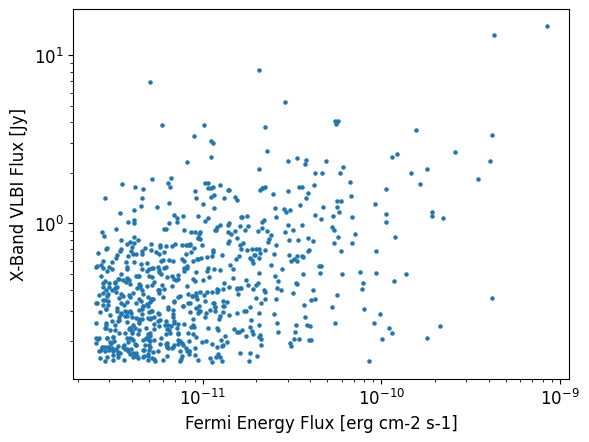

In [16]:
plt.scatter(energy_fluxes, radio_flux, s=5)
#plt.xlim(0,5e-10)
#plt.ylim(0,16)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fermi Energy Flux [erg cm-2 s-1]", fontsize="large")
plt.ylabel("X-Band VLBI Flux [Jy]", fontsize="large")

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")
plt.savefig("fermi_rfc_flux_comparison", dpi=200, bbox_inches="tight")

In [17]:
sum(ra_mask), sum(de_mask)

(0, 0)

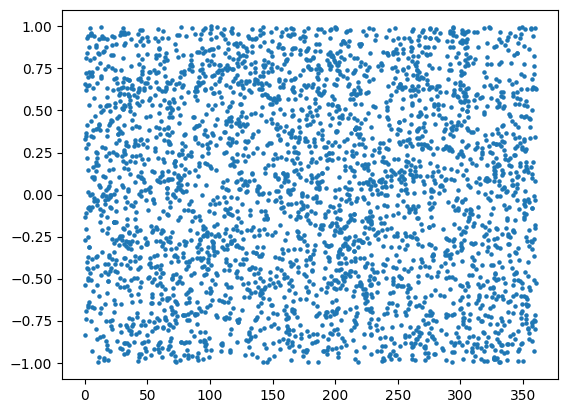

In [18]:
plt.scatter(rd_cat_obj.data['ra_deg'], np.sin(rd_cat_obj.data['dec_rad']), s=5)

In [19]:
rd_cat_obj.scramble()

,Comm name,Source_Name,ra_deg,dec_deg,N of obs,S band map,S band unresolved,C band map,C band unresolved,X band map,X band unresolved,U band map,U band unresolved,K band map,K band unresolved,ra_rad,dec_rad,bkg_pdf
0,2357-326,J0000-3221,336.259220,-52.407324,17,0.581,0.436,-9.99,-9.99,0.278,0.133,-9.99,-9.99,-9.99,-9.99,5.868831,-0.914680,8.039185e-08
1,2358+406,J0000+4054,68.554758,58.181860,16,0.802,0.116,-9.99,-9.99,0.238,0.051,-9.99,-9.99,-9.99,-9.99,1.196506,1.015465,6.806367e-08
2,2358-161,J0001-1551,292.191870,9.847158,18,0.313,0.179,-9.99,-9.99,0.192,0.099,-9.99,-9.99,-9.99,-9.99,5.099710,0.171865,7.083819e-08
3,2358+189,J0001+1914,249.829162,51.898203,770,0.255,0.195,0.156,0.127,0.251,0.186,-9.99,-9.99,-9.99,-9.99,4.360341,0.905795,8.732037e-08
4,2358-080,J0001-0746,83.845662,-61.037579,28,0.209,0.106,-9.99,-9.99,0.175,0.053,-9.99,-9.99,-9.99,-9.99,1.463383,-1.065307,7.909119e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3378,2355+042,J2358+0430,196.152442,-32.598091,23,0.188,0.165,-9.99,-9.99,0.153,0.105,-9.99,-9.99,-9.99,-9.99,3.423506,-0.568944,8.536415e-08
3379,2356+196,J2358+1955,227.273965,-18.735272,85,0.773,0.502,-9.99,-9.99,0.469,0.221,0.377,0.182,-9.99,-9.99,3.966679,-0.326992,9.311820e-08
3380,2356+390,J2358+3922,5.462036,-34.960243,16,0.326,0.117,-9.99,-9.99,0.305,0.180,-9.99,-9.99,-9.99,-9.99,0.095331,-0.610171,7.377937e-08
3381,2356+385,J2359+3850,12.116379,51.348843,9256,0.416,0.297,-9.99,-9.99,0.320,0.206,-9.99,-9.99,-9.99,-9.99,0.211471,0.896206,7.709558e-08


In [20]:
bl_cat_obj = Fermi4FGLBlazarCatalogue()

In [21]:
bl_cat = bl_cat_obj.data
bl_cat["ra_rad"]

array([343.4963, 228.2147, 166.1187, ..., 192.2443, 197.6525, 293.582 ],
      dtype='>f4')

In [22]:
for dtype in bl_cat.dtypes:
    print(dtype.descr)

AttributeError: 'numpy.ndarray' object has no attribute 'dtypes'

In [23]:
bl_cat.to_records(index=False)[bl_cat.to_records(index=False).dtype.descr[0][0]]

AttributeError: 'numpy.ndarray' object has no attribute 'to_records'

In [24]:
a = 4.84578973489584908520
type(np.float64(a))

numpy.float64

In [25]:
bl_cat[bl_cat.to_records(index=False).dtype.descr[0][0]]

AttributeError: 'numpy.ndarray' object has no attribute 'to_records'

In [26]:
bl_cat

array([(b'4FGL J2253.9+1609', 1, 343.4963,  16.1506,  86.11852 , -38.18486 , 465.1539  , 8.6901984e-08, 5.5873567e-10, 1.1148474e-09, 5.3422553e-12, b'PLSuperExpCutoff2', 2.396776 , 0.00325315,  232.35162, 2.1620116, 0.00693491,  0.10028907, 0.00253769, 0, b'FSRQ', b'3C 454.3', 1.        , 0.9995651 , b'identified', 343.49061642,  16.14821135, 6.79999985e-08, b'RFC J2253+1608', 0.859 , b'LSP', 1.2852867e+13, 4.6321010e-11, 5.6365367e+04, 0.8533719 ,  0.20116921,  80.5114),
       (b'4FGL J1512.8-0906', 1, 228.2147,  -9.1064, 351.28754 ,  40.13122 , 238.70695 , 3.4685627e-08, 3.0608727e-10, 4.5896065e-10, 3.8530143e-12, b'LogParabola', 2.3825283, 0.00517185,  723.6382 , 2.36835  , 0.00929222,  0.05569334, 0.00352816, 0, b'FSRQ', b'PKS 1510-089', 1.        , 0.9998213 , b'identified', 228.21055387,  -9.09995274, 6.79999985e-08, b'RFC J1512-0905', 0.36  , b'LSP', 1.0964782e+13, 1.1134020e-11, 5.9300635e+03, 0.47162834,  0.11130514, 230.846 ),
       (b'4FGL J1104.4+3812', 1, 166.1187,  38

In [27]:
for b in bl_cat:
    print(b)

(b'4FGL J2253.9+1609', 1, 343.4963, 16.1506, 86.11852, -38.18486, 465.1539, 8.6901984e-08, 5.5873567e-10, 1.1148474e-09, 5.3422553e-12, b'PLSuperExpCutoff2', 2.396776, 0.00325315, 232.35162, 2.1620116, 0.00693491, 0.10028907, 0.00253769, 0, b'FSRQ', b'3C 454.3', 1., 0.9995651, b'identified', 343.49061642, 16.14821135, 6.79999985e-08, b'RFC J2253+1608', 0.859, b'LSP', 1.2852867e+13, 4.632101e-11, 56365.367, 0.8533719, 0.20116921, 80.5114)
(b'4FGL J1512.8-0906', 1, 228.2147, -9.1064, 351.28754, 40.13122, 238.70695, 3.4685627e-08, 3.0608727e-10, 4.5896065e-10, 3.8530143e-12, b'LogParabola', 2.3825283, 0.00517185, 723.6382, 2.36835, 0.00929222, 0.05569334, 0.00352816, 0, b'FSRQ', b'PKS 1510-089', 1., 0.9998213, b'identified', 228.21055387, -9.09995274, 6.79999985e-08, b'RFC J1512-0905', 0.36, b'LSP', 1.0964782e+13, 1.113402e-11, 5930.0635, 0.47162834, 0.11130514, 230.846)
(b'4FGL J1104.4+3812', 1, 166.1187, 38.207, 179.83292, 65.035706, 325.52264, 3.5663206e-08, 3.0721156e-10, 4.4957787e-1

In [ ]:
bl_cat['bkg_pdf']

In [ ]:
bl_cat

In [ ]:
scramble = bl_cat_obj.scramble()

In [ ]:
plt.scatter(scramble['ra_deg'], np.sin(scramble['dec_rad']), s=8)
plt.scatter(bl_cat['ra_deg'], np.sin(bl_cat['dec_rad']), s=8)
plt.xlim(0, 360.)
plt.ylim(-1., 1.)

In [ ]:
bl_cat['bkg_pdf']

In [ ]:
AverageFluxWeightHypothesis.weight_catalogue(bl_cat)

In [ ]:
bl_cat["Energy_Flux100"]